<a href="https://colab.research.google.com/github/cece7141-ctrl/Web-and-Social-Analytics/blob/main/Data_Mining_Course_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master


  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-pyblb453
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-pyblb453
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import pandas as pd
import numpy as np

from sklearn import preprocessing

from sklearn.model_selection import train_test_split

from sklearn import tree

In [ ]:
from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import GridSearchCV

from sklearn import metrics

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report

from sklearn.metrics import RocCurveDisplay

import plotly.express as px

**Data Exploration/Preparation**

In [ ]:
df = pd.read_csv('/content/loan_approval_data.csv')
df.head()

/tmp/ipython-input-895425697.py:1: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/loan_approval_data.csv')


,id,age,Sex,Education_Qualifications,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,Credit_Application_Acceptance
0,35437,21.0,M,Unknown,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,Approved,-2426900,0.0
1,53756,21.0,M,Unknown,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,Approved,-111739,0.0
2,42205,23.0,M,Unknown,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,Approved,-89000,0.0
3,19180,40.0,M,Unknown,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,Approved,35000,0.0
4,28072,40.0,M,Unknown,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,Approved,35000,0.0


In [ ]:
df.loan_approval_status.unique()

array(['Approved', 'APPROVED', 'APPROVED ', 'Declined ', 'DECLINED ',
       'Reject', nan, 'Accept', 'Accept '], dtype=object)

In [ ]:
df.payment_default_on_file.unique()

array(['N', 'Y', nan, 'NO', 'YES'], dtype=object)

In [ ]:
df.columns

Index(['id', 'age', 'Sex', 'Education_Qualifications', 'income',
       'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status', 'max_allowed_loan',
       'Credit_Application_Acceptance'],
      dtype='object')

In [ ]:
df['payment_default_on_file'] = df['payment_default_on_file'].map({'N':1 ,'NO': 1 , 'Y':0,'YES': 0})

In [ ]:
df.describe()

,id,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan,Credit_Application_Acceptance
count,58645.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58640.000000,58645.000000,5.864500e+04,58644.000000
mean,29322.000000,6.404617e+04,4.703487,9217.556518,10.685988,0.159238,0.851637,5.813556,2.823538e+05,0.142385
std,16929.497605,3.793111e+04,4.004982,5563.807384,3.161955,0.091692,0.355462,4.029196,5.148478e+07,0.349447
min,0.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,0.000000,2.000000,-2.426900e+06,0.000000
25%,14661.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,3.800300e+04,0.000000
50%,29322.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,6.239200e+04,0.000000
75%,43983.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,9.271600e+04,0.000000
max,58644.000000,1.900000e+06,150.000000,35000.000000,150.000000,0.830000,1.000000,30.000000,1.246799e+10,1.000000


In [ ]:
df['loan_approval_status'] = df['loan_approval_status'].map({'Declined ':1 ,'DECLINED ': 1, 'Reject': 1 , 'Approved':0,'APPROVED': 0,'APPROVED ':0, 'Accept':0, 'Accept ':0 })

In [ ]:
df.describe()

,id,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,Credit_Application_Acceptance
count,58645.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58640.000000,58645.000000,58644.000000,5.864500e+04,58644.000000
mean,29322.000000,6.404617e+04,4.703487,9217.556518,10.685988,0.159238,0.851637,5.813556,0.142385,2.823538e+05,0.142385
std,16929.497605,3.793111e+04,4.004982,5563.807384,3.161955,0.091692,0.355462,4.029196,0.349447,5.148478e+07,0.349447
min,0.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,0.000000,2.000000,0.000000,-2.426900e+06,0.000000
25%,14661.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,3.800300e+04,0.000000
50%,29322.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,6.239200e+04,0.000000
75%,43983.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,9.271600e+04,0.000000
max,58644.000000,1.900000e+06,150.000000,35000.000000,150.000000,0.830000,1.000000,30.000000,1.000000,1.246799e+10,1.000000


In [ ]:
df[['income','emplyment_length', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio',
       'credit_history_length']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.685988,3.161955,-11.14,7.88,10.75,12.99,150.00
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00


In [ ]:
df.describe(include='object')

,age,Sex,Education_Qualifications,home_ownership,loan_intent
count,58639.0,221,58645,58645,58645
unique,104.0,2,6,4,6
top,22.0,M,Unknown,RENT,EDUCATION
freq,5903.0,126,58303,30594,12271


In [ ]:
df[['income','emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   income                   58645 non-null  int64  
 1   emplyment_length         58645 non-null  int64  
 2   loan_intent              58645 non-null  object 
 3   loan_amount              58645 non-null  int64  
 4   loan_interest_rate       58634 non-null  float64
 5   loan_income_ratio        58645 non-null  float64
 6   payment_default_on_file  58640 non-null  float64
 7   credit_history_length    58645 non-null  int64  
 8   loan_approval_status     58644 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 4.0+ MB


In [ ]:
df['home_ownership'].unique()

array(['OWN', 'RENT', 'MORTGAGE', 'OTHER'], dtype=object)

In [ ]:
(58303/58645)*100

99.41683007929065

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             58645 non-null  int64  
 1   age                            58639 non-null  object 
 2   Sex                            221 non-null    object 
 3   Education_Qualifications       58645 non-null  object 
 4   income                         58645 non-null  int64  
 5   home_ownership                 58645 non-null  object 
 6   emplyment_length               58645 non-null  int64  
 7   loan_intent                    58645 non-null  object 
 8   loan_amount                    58645 non-null  int64  
 9   loan_interest_rate             58634 non-null  float64
 10  loan_income_ratio              58645 non-null  float64
 11  payment_default_on_file        58640 non-null  float64
 12  credit_history_length          58645 non-null 

In [ ]:
df.shape

(58645, 16)

In [ ]:
df.age.unique()

array([21.0, 23.0, 40.0, 20.0, 22.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0,
       30.0, 31.0, 32.0, 33.0, nan, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0,
       41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0,
       52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 60.0, 61.0, 62.0, 64.0,
       65.0, 66.0, 70.0, 73.0, 76.0, 80.0, 69.0, '23', '27', '29', '25',
       '39', '22', '33', '31', '35', '26', '37', '34', '28', '21', '24',
       '46', '47', '41', '30', '49', '43', '42', '45', '38', '32', '51',
       '53', '36', '48', '52', '44', '57', '54', '62', '56', '20', '61',
       '55', '60', '58', '64', '70', '50', '59', '69', '123', '65', '66',
       '156', '-30', 'Twenty Seven', 'Twenty Three', 'Thirty', '84'],
      dtype=object)

In [ ]:
df[['income','emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status']].isna().sum()/len(df)*100

,0
income,0.000000
emplyment_length,0.000000
loan_intent,0.000000
loan_amount,0.000000
loan_interest_rate,0.018757
loan_income_ratio,0.000000
payment_default_on_file,0.008526
credit_history_length,0.000000
loan_approval_status,0.001705


In [ ]:
df.isna().sum()/len(df)*100

,0
id,0.000000
age,0.010231
Sex,99.623156
Education_Qualifications,0.000000
income,0.000000
home_ownership,0.000000
emplyment_length,0.000000
loan_intent,0.000000
loan_amount,0.000000
loan_interest_rate,0.018757


In [ ]:
df.dropna()

,id,age,Sex,Education_Qualifications,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan,Credit_Application_Acceptance
0,35437,21.0,M,Unknown,12000,OWN,0,EDUCATION,15000,6.99,0.12,1.0,4,0.0,-2426900,0.0
1,53756,21.0,M,Unknown,13200,OWN,2,EDUCATION,25000,16.77,0.19,0.0,3,0.0,-111739,0.0
2,42205,23.0,M,Unknown,9600,RENT,5,MEDICAL,30000,12.42,0.31,1.0,3,0.0,-89000,0.0
3,19180,40.0,M,Unknown,182004,RENT,3,EDUCATION,35000,8.00,0.19,1.0,11,0.0,35000,0.0
4,28072,40.0,M,Unknown,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,1.0,14,0.0,35000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,21597,40.0,F,Unknown,100000,RENT,1,HOMEIMPROVEMENT,7000,9.63,0.07,1.0,17,0.0,7000,0.0
217,29269,40.0,F,Unknown,50000,MORTGAGE,5,HOMEIMPROVEMENT,7000,7.49,0.14,1.0,11,0.0,7000,0.0
218,32374,40.0,F,Unknown,55000,MORTGAGE,5,VENTURE,7000,9.99,0.13,1.0,14,0.0,7000,0.0
219,32655,40.0,F,Unknown,225000,MORTGAGE,3,EDUCATION,7000,9.99,0.03,1.0,16,0.0,7000,0.0


In [ ]:
df.drop(['id', 'age', 'Sex', 'Education_Qualifications', 'home_ownership', 'Credit_Application_Acceptance'], axis=1, inplace=True)


In [ ]:
df.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,12000,0,EDUCATION,15000,6.99,0.12,1.0,4,0.0,-2426900
1,13200,2,EDUCATION,25000,16.77,0.19,0.0,3,0.0,-111739
2,9600,5,MEDICAL,30000,12.42,0.31,1.0,3,0.0,-89000
3,182004,3,EDUCATION,35000,8.00,0.19,1.0,11,0.0,35000
4,90000,3,HOMEIMPROVEMENT,35000,12.42,0.39,1.0,14,0.0,35000


In [ ]:
df['loan_income_ratio'].unique()

array([0.12 , 0.19 , 0.31 , 0.39 , 0.23 , 0.17 , 0.22 , 0.3  , 0.42 ,
       0.29 , 0.36 , 0.21 , 0.14 , 0.11 , 0.16 , 0.33 , 0.25 , 0.28 ,
       0.26 , 0.1  , 0.15 , 0.18 , 0.2  , 0.03 , 0.13 , 0.24 , 0.08 ,
       0.09 , 0.07 , 0.32 , 0.06 , 0.05 , 0.27 , 0.04 , 0.02 , 0.01 ,
       0.38 , 0.44 , 0.4  , 0.37 , 0.43 , 0.34 , 0.47 , 0.35 , 0.5  ,
       0.41 , 0.48 , 0.46 , 0.45 , 0.51 , 0.49 , 0.52 , 0.59 , 0.56 ,
       0.83 , 0.54 , 0.   , 0.53 , 0.63 , 0.384, 0.55 ])

In [ ]:
df.describe()

,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58640.000000,58645.000000,58644.000000,5.864500e+04
mean,6.404617e+04,4.703487,9217.556518,10.685988,0.159238,0.851637,5.813556,0.142385,2.823538e+05
std,3.793111e+04,4.004982,5563.807384,3.161955,0.091692,0.355462,4.029196,0.349447,5.148478e+07
min,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,0.000000,2.000000,0.000000,-2.426900e+06
25%,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,3.800300e+04
50%,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,6.239200e+04
75%,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,9.271600e+04
max,1.900000e+06,150.000000,35000.000000,150.000000,0.830000,1.000000,30.000000,1.000000,1.246799e+10


In [ ]:
df.describe(include='object')

,loan_intent
count,58645
unique,6
top,EDUCATION
freq,12271


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   income                   58645 non-null  int64  
 1   emplyment_length         58645 non-null  int64  
 2   loan_intent              58645 non-null  object 
 3   loan_amount              58645 non-null  int64  
 4   loan_interest_rate       58634 non-null  float64
 5   loan_income_ratio        58645 non-null  float64
 6   payment_default_on_file  58640 non-null  float64
 7   credit_history_length    58645 non-null  int64  
 8   loan_approval_status     58644 non-null  float64
 9   max_allowed_loan         58645 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 4.5+ MB


In [ ]:
#df['age']=pd.to_numeric(df['age'], errors='coerce')
#df.info()

In [ ]:
LTI_fig = px.box(df, x='loan_income_ratio')
LTI_fig.show()

In [ ]:
acceptance_fig = px.histogram(df, x='loan_approval_status')
acceptance_fig.show()

In [ ]:
maxloan_fig = px.box(df, x='max_allowed_loan')
maxloan_fig.show()

In [ ]:
df['loan_approval_status'].unique()

array([ 0.,  1., nan])

In [ ]:
df['payment_default_on_file'].unique()

array([ 1.,  0., nan])

In [ ]:
df['loan_interest_rate'].unique()

array([  6.99,  16.77,  12.42,   8.  ,   7.9 ,  11.89,  16.82,  10.25,
        18.67,  11.97,  12.18,  18.25,  10.75,  10.99,  11.83,  10.65,
        14.72,  15.95,  14.54,  18.62,  13.47,  11.86,   6.03,  14.09,
        13.23,   9.88,  15.27,  10.37,  11.12,  12.99,  12.68,   7.49,
        14.27,   6.76,   6.62,  11.71,   7.88,  11.14,   9.99,  14.42,
         8.94,   6.17,  12.21,  11.26,  13.11,  14.96,   5.42,  14.26,
        16.89,  13.43,  12.84,  10.62,  11.49,   9.91,   7.29,  13.49,
        13.48,  12.53,  11.99,   5.79,  12.61,  13.99,  12.87,  15.2 ,
        11.36,   7.51,  10.  ,   8.59,   5.99,   8.49,  13.61,   7.14,
        15.28,  10.74,   9.63,  11.48,  10.36,   6.91,  10.95,  10.59,
        11.11,  14.11,   9.45,  13.72,  15.58,  10.38,  14.83,  16.29,
        13.57,   9.25,   9.32,   9.62,   7.66,  50.6 ,   7.74,   8.88,
         9.64,  12.69,  16.45,  14.79,  13.22,  13.16,  11.78,  13.85,
         7.75,  15.05,  10.96,  11.28,   6.92,  14.65,   7.68,   6.39,
      

In [ ]:
emp_fig = px.box(df, x='loan_interest_rate')
emp_fig.show()

In [ ]:
df=df[(df.loan_interest_rate > 5) & (df.loan_interest_rate < 37) ]
df.describe()

,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,5.862700e+04,58627.000000,58627.000000,58627.000000,58627.000000,58622.000000,58627.000000,58626.000000,5.862700e+04
mean,6.404840e+04,4.703737,9217.115868,10.678185,0.159224,0.851609,5.813482,0.142309,2.824240e+05
std,3.793339e+04,4.004959,5563.941518,3.036414,0.091694,0.355491,4.029514,0.349370,5.149268e+07
min,4.200000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,-2.426900e+06
25%,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,3.803500e+04
50%,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,6.239700e+04
75%,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,9.271650e+04
max,1.900000e+06,150.000000,35000.000000,35.800000,0.830000,1.000000,30.000000,1.000000,1.246799e+10


In [ ]:
emp_fig = px.box(df, x='loan_interest_rate')
emp_fig.show()

In [ ]:
df['loan_intent'].unique()

array(['EDUCATION', 'MEDICAL', 'HOMEIMPROVEMENT', 'VENTURE',
       'DEBTCONSOLIDATION', 'PERSONAL'], dtype=object)

In [ ]:
df.dropna()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,12000,0,EDUCATION,15000,6.99,0.12,1.0,4,0.0,-2426900
1,13200,2,EDUCATION,25000,16.77,0.19,0.0,3,0.0,-111739
2,9600,5,MEDICAL,30000,12.42,0.31,1.0,3,0.0,-89000
3,182004,3,EDUCATION,35000,8.00,0.19,1.0,11,0.0,35000
4,90000,3,HOMEIMPROVEMENT,35000,12.42,0.39,1.0,14,0.0,35000
...,...,...,...,...,...,...,...,...,...,...
58640,1200000,16,DEBTCONSOLIDATION,16000,6.92,0.13,1.0,5,0.0,1903960
58641,1200000,2,PERSONAL,10000,7.51,0.01,1.0,9,0.0,1909968
58642,1900000,6,EDUCATION,1500,15.62,0.00,0.0,3,0.0,2088491
58643,1839784,0,VENTURE,8000,8.00,0.04,1.0,3,0.0,2291708


In [ ]:

credit_history_length_fig = px.box(df, x='credit_history_length')
credit_history_length_fig.show()

In [ ]:
loan_amount_fig = px.box(df, x='loan_amount')
loan_amount_fig.show()

In [ ]:
Age_Salary_Scatter_fig = px.scatter(x=df['emplyment_length'], y=df['income'])
Age_Salary_Scatter_fig.show()


In [ ]:
emp_fig = px.box(df, x='emplyment_length')
emp_fig.show()

In [ ]:
df=df[(df.emplyment_length < 123) ]
df.describe()


,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,5.862400e+04,58624.000000,58624.000000,58624.000000,58624.000000,58619.000000,58624.000000,58623.000000,5.862400e+04
mean,6.404697e+04,4.697223,9216.794350,10.678020,0.159224,0.851635,5.813575,0.142299,2.824350e+05
std,3.793032e+04,3.899094,5563.432478,3.036376,0.091692,0.355464,4.029579,0.349360,5.149400e+07
min,4.200000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,-2.426900e+06
25%,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,3.803800e+04
50%,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,6.240000e+04
75%,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,9.271625e+04
max,1.900000e+06,41.000000,35000.000000,35.800000,0.830000,1.000000,30.000000,1.000000,1.246799e+10


In [ ]:
#emp_fig = px.box(df, x='age')
#emp_fig.show()

In [ ]:
#df=df[(df.age > 0) & (df.age < 85) ]
#df.describe()

In [ ]:
emp_fig = px.box(df, x='emplyment_length')
emp_fig.show()

In [ ]:
income_fig = px.box(df, x='income')
income_fig.show()

In [ ]:
df=df[(df.income <= 160000)]
df.describe()


,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,57911.000000,57911.000000,57911.000000,57911.000000,57911.000000,57906.000000,57911.000000,57910.000000,5.791100e+04
mean,61883.705721,4.682858,9145.831569,10.681935,0.160232,0.851190,5.791801,0.143775,2.819694e+05
std,27149.413238,3.883103,5489.067373,3.039480,0.091663,0.355904,4.015427,0.350864,5.181002e+07
min,4200.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,-2.426900e+06
25%,42000.000000,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,3.787700e+04
50%,57240.000000,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,6.197600e+04
75%,75000.000000,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,9.111050e+04
max,160000.000000,41.000000,35000.000000,35.800000,0.830000,1.000000,30.000000,1.000000,1.246799e+10


In [ ]:
df['payment_default_on_file'].unique()

array([ 1.,  0., nan])

In [ ]:
df=df[(df.max_allowed_loan>=0) & (df.max_allowed_loan < 100000000)]


In [ ]:
maxloan1_fig = px.box(df, x='max_allowed_loan')
maxloan1_fig.show()

In [ ]:
income_fig = px.box(df, x='income')
income_fig.show()

In [ ]:
#def find_outliers_IQR(df):
 # q1=df.quantile(0.25)
#  q3=df.quantile(0.75)
 # IQR=q3-q1
 # outliers = df[((df<(q1-1.5*IQR))|(df>(q3+1.5*IQR)))]
  #return outliers


In [ ]:
df.tail()


,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
58375,160000,14,VENTURE,10000,10.59,0.07,1.0,11,0.0,290790
58384,160000,5,VENTURE,10000,10.65,0.06,1.0,16,0.0,293962
58396,160000,8,VENTURE,15000,7.88,0.09,1.0,11,0.0,296952
58398,158000,13,HOMEIMPROVEMENT,11000,8.49,0.07,1.0,15,0.0,297059
58421,160000,1,PERSONAL,10000,9.32,0.06,1.0,12,0.0,309990


In [ ]:
df.describe()

,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,57907.000000,57907.000000,57907.000000,57907.000000,57907.000000,57902.000000,57907.000000,57906.000000,57907.000000
mean,61885.652546,4.682923,9145.150880,10.681924,0.160231,0.851197,5.791994,0.143785,66723.672630
std,27147.474129,3.883148,5488.107833,3.039397,0.091663,0.355897,4.015494,0.350874,46667.002736
min,4200.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,42000.000000,2.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,37881.500000
50%,57240.000000,4.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,61976.000000
75%,75000.000000,7.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,91110.500000
max,160000.000000,41.000000,35000.000000,35.800000,0.830000,1.000000,30.000000,1.000000,309990.000000


In [ ]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

label_encoder = preprocessing.LabelEncoder()
df['loan_intent']= label_encoder.fit_transform(df['loan_intent'])

df.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
4,90000,3,2,35000,12.42,0.39,1.0,14,0.0,35000
5,131004,9,5,30000,7.90,0.23,1.0,13,0.0,30000
6,150000,9,0,25000,11.89,0.17,1.0,11,0.0,25000
7,132000,3,2,25000,16.82,0.22,1.0,17,0.0,25000
8,80000,2,0,25000,10.25,0.31,1.0,11,0.0,25000


In [ ]:
df.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
4,90000,3,2,35000,12.42,0.39,1.0,14,0.0,35000
5,131004,9,5,30000,7.90,0.23,1.0,13,0.0,30000
6,150000,9,0,25000,11.89,0.17,1.0,11,0.0,25000
7,132000,3,2,25000,16.82,0.22,1.0,17,0.0,25000
8,80000,2,0,25000,10.25,0.31,1.0,11,0.0,25000


In [ ]:
df.describe()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
count,57907.000000,57907.000000,57907.000000,57907.000000,57907.000000,57907.000000,57902.000000,57907.000000,57906.000000,57907.000000
mean,61885.652546,4.682923,2.519505,9145.150880,10.681924,0.160231,0.851197,5.791994,0.143785,66723.672630
std,27147.474129,3.883148,1.723078,5488.107833,3.039397,0.091663,0.355897,4.015494,0.350874,46667.002736
min,4200.000000,0.000000,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,42000.000000,2.000000,1.000000,5000.000000,7.880000,0.090000,1.000000,3.000000,0.000000,37881.500000
50%,57240.000000,4.000000,3.000000,8000.000000,10.750000,0.140000,1.000000,4.000000,0.000000,61976.000000
75%,75000.000000,7.000000,4.000000,12000.000000,12.990000,0.210000,1.000000,8.000000,0.000000,91110.500000
max,160000.000000,41.000000,5.000000,35000.000000,35.800000,0.830000,1.000000,30.000000,1.000000,309990.000000


In [ ]:
df_complete = df.dropna()
df_complete


,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
4,90000,3,2,35000,12.42,0.39,1.0,14,0.0,35000
5,131004,9,5,30000,7.90,0.23,1.0,13,0.0,30000
6,150000,9,0,25000,11.89,0.17,1.0,11,0.0,25000
7,132000,3,2,25000,16.82,0.22,1.0,17,0.0,25000
8,80000,2,0,25000,10.25,0.31,1.0,11,0.0,25000
...,...,...,...,...,...,...,...,...,...,...
58375,160000,14,5,10000,10.59,0.07,1.0,11,0.0,290790
58384,160000,5,5,10000,10.65,0.06,1.0,16,0.0,293962
58396,160000,8,5,15000,7.88,0.09,1.0,11,0.0,296952
58398,158000,13,2,11000,8.49,0.07,1.0,15,0.0,297059


In [ ]:
df[['income','emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status']].isna().sum()/len(df)*100

,0
income,0.000000
emplyment_length,0.000000
loan_intent,0.000000
loan_amount,0.000000
loan_interest_rate,0.000000
loan_income_ratio,0.000000
payment_default_on_file,0.008635
credit_history_length,0.000000
loan_approval_status,0.001727


In [ ]:
df_complete.isna().sum()/len(df)*100

,0
income,0.0
emplyment_length,0.0
loan_intent,0.0
loan_amount,0.0
loan_interest_rate,0.0
loan_income_ratio,0.0
payment_default_on_file,0.0
credit_history_length,0.0
loan_approval_status,0.0
max_allowed_loan,0.0


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
income,57907.0,61885.652546,27147.474129,4200.00,42000.00,57240.00,75000.00,160000.00
emplyment_length,57907.0,4.682923,3.883148,0.00,2.00,4.00,7.00,41.00
loan_intent,57907.0,2.519505,1.723078,0.00,1.00,3.00,4.00,5.00
loan_amount,57907.0,9145.150880,5488.107833,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,57907.0,10.681924,3.039397,5.42,7.88,10.75,12.99,35.80
loan_income_ratio,57907.0,0.160231,0.091663,0.00,0.09,0.14,0.21,0.83
payment_default_on_file,57902.0,0.851197,0.355897,0.00,1.00,1.00,1.00,1.00
credit_history_length,57907.0,5.791994,4.015494,2.00,3.00,4.00,8.00,30.00
loan_approval_status,57906.0,0.143785,0.350874,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,57907.0,66723.672630,46667.002736,0.00,37881.50,61976.00,91110.50,309990.00


In [ ]:
df_complete['payment_default_on_file']=df_complete['payment_default_on_file'].astype(int)
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57901 entries, 4 to 58421
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   income                   57901 non-null  int64  
 1   emplyment_length         57901 non-null  int64  
 2   loan_intent              57901 non-null  int64  
 3   loan_amount              57901 non-null  int64  
 4   loan_interest_rate       57901 non-null  float64
 5   loan_income_ratio        57901 non-null  float64
 6   payment_default_on_file  57901 non-null  int64  
 7   credit_history_length    57901 non-null  int64  
 8   loan_approval_status     57901 non-null  float64
 9   max_allowed_loan         57901 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 4.9 MB


/tmp/ipython-input-2135803703.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
#df_complete['age']=df_complete['age'].astype(int)
#df_complete.info()

In [ ]:
df_complete['loan_approval_status']=df_complete['loan_approval_status'].astype(int)
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57901 entries, 4 to 58421
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   income                   57901 non-null  int64  
 1   emplyment_length         57901 non-null  int64  
 2   loan_intent              57901 non-null  int64  
 3   loan_amount              57901 non-null  int64  
 4   loan_interest_rate       57901 non-null  float64
 5   loan_income_ratio        57901 non-null  float64
 6   payment_default_on_file  57901 non-null  int64  
 7   credit_history_length    57901 non-null  int64  
 8   loan_approval_status     57901 non-null  int64  
 9   max_allowed_loan         57901 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 4.9 MB


/tmp/ipython-input-1011171827.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_complete['loan_intent'].unique()

array([2, 5, 0, 1, 4, 3])

In [ ]:
df_complete['payment_default_on_file'].unique()

array([1, 0])

In [ ]:
df_complete['loan_approval_status'].unique()

array([0, 1])

In [ ]:
df_complete.head(20)

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
4,90000,3,2,35000,12.42,0.39,1,14,0,35000
5,131004,9,5,30000,7.90,0.23,1,13,0,30000
6,150000,9,0,25000,11.89,0.17,1,11,0,25000
7,132000,3,2,25000,16.82,0.22,1,17,0,25000
8,80000,2,0,25000,10.25,0.31,1,11,0,25000
9,80000,9,5,25000,18.67,0.30,1,17,0,25000
10,60000,5,5,25000,11.97,0.42,0,12,0,25000
11,85000,3,2,25000,12.18,0.29,1,16,0,25000
12,69996,19,1,25000,18.25,0.36,1,14,0,25000
14,120000,9,4,25000,10.75,0.21,1,12,0,25000


In [ ]:
df_complete.to_csv(r'/content/loan_approval_data_clean.csv', index=False)

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
dfclean = pd.read_csv('/content/loan_approval_data_clean.csv')
df.describe(include="all").transpose()


,count,mean,std,min,25%,50%,75%,max
income,57907.00,61885.65,27147.47,4200.00,42000.00,57240.00,75000.00,160000.00
emplyment_length,57907.00,4.68,3.88,0.00,2.00,4.00,7.00,41.00
loan_intent,57907.00,2.52,1.72,0.00,1.00,3.00,4.00,5.00
loan_amount,57907.00,9145.15,5488.11,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,57907.00,10.68,3.04,5.42,7.88,10.75,12.99,35.80
loan_income_ratio,57907.00,0.16,0.09,0.00,0.09,0.14,0.21,0.83
payment_default_on_file,57902.00,0.85,0.36,0.00,1.00,1.00,1.00,1.00
credit_history_length,57907.00,5.79,4.02,2.00,3.00,4.00,8.00,30.00
loan_approval_status,57906.00,0.14,0.35,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,57907.00,66723.67,46667.00,0.00,37881.50,61976.00,91110.50,309990.00


In [ ]:
dfclean = pd.read_csv('/content/loan_approval_data_clean.csv')
emp_fig = px.histogram(df, x='loan_intent')
emp_fig.show()

In [ ]:

emp_fig = px.box(dfclean, x='loan_income_ratio')
emp_fig.show()

In [ ]:
emp_fig = px.histogram(dfclean, x='payment_default_on_file')
emp_fig.show()

In [ ]:
emp_fig = px.box(dfclean, x='credit_history_length')
emp_fig.show()

In [ ]:
emp_fig = px.histogram(dfclean, x='loan_approval_status')
emp_fig.show()

In [ ]:
dfclean.columns

Index(['income', 'emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status', 'max_allowed_loan'],
      dtype='object')

In [ ]:
dfclean.shape

(57901, 10)

In [ ]:
dfclean = pd.read_csv('/content/loan_approval_data_clean.csv')
emp_fig = px.box(dfclean, x='loan_amount')
emp_fig.show()

In [ ]:
dfclean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57901 entries, 0 to 57900
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   income                   57901 non-null  int64  
 1   emplyment_length         57901 non-null  int64  
 2   loan_intent              57901 non-null  int64  
 3   loan_amount              57901 non-null  int64  
 4   loan_interest_rate       57901 non-null  float64
 5   loan_income_ratio        57901 non-null  float64
 6   payment_default_on_file  57901 non-null  int64  
 7   credit_history_length    57901 non-null  int64  
 8   loan_approval_status     57901 non-null  int64  
 9   max_allowed_loan         57901 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 4.4 MB


In [ ]:
colnumeric = ['income', 'emplyment_length', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio',
       'credit_history_length']

scaler = StandardScaler()
dfclean[colnumeric] = scaler.fit_transform(dfclean[colnumeric])
dfclean.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,1.04,-0.43,2,4.71,0.57,2.51,1,2.04,0,35000
1,2.55,1.11,5,3.80,-0.92,0.76,1,1.79,0,30000
2,3.25,1.11,0,2.89,0.40,0.11,1,1.30,0,25000
3,2.58,-0.43,2,2.89,2.02,0.65,1,2.79,0,25000
4,0.67,-0.69,0,2.89,-0.14,1.63,1,1.30,0,25000


In [ ]:
dfclean.head(20)


,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,1.04,-0.43,2,4.71,0.57,2.51,1,2.04,0,35000
1,2.55,1.11,5,3.80,-0.92,0.76,1,1.79,0,30000
2,3.25,1.11,0,2.89,0.40,0.11,1,1.30,0,25000
3,2.58,-0.43,2,2.89,2.02,0.65,1,2.79,0,25000
4,0.67,-0.69,0,2.89,-0.14,1.63,1,1.30,0,25000
5,0.67,1.11,5,2.89,2.63,1.53,1,2.79,0,25000
6,-0.07,0.08,5,2.89,0.42,2.83,0,1.55,0,25000
7,0.85,-0.43,2,2.89,0.49,1.42,1,2.54,0,25000
8,0.30,3.69,1,2.89,2.49,2.18,1,2.04,0,25000
9,2.14,1.11,4,2.89,0.02,0.54,1,1.55,0,25000


In [ ]:
dfclean.to_csv(r'/content/loan_approval_data_scaled.csv', index=False)

**Predictive Classification Modeling**

In [ ]:
lr = pd.read_csv('/content/loan_approval_data_scaled.csv')
lr.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,1.04,-0.43,2,4.71,0.57,2.51,1,2.04,0,35000
1,2.55,1.11,5,3.80,-0.92,0.76,1,1.79,0,30000
2,3.25,1.11,0,2.89,0.40,0.11,1,1.30,0,25000
3,2.58,-0.43,2,2.89,2.02,0.65,1,2.79,0,25000
4,0.67,-0.69,0,2.89,-0.14,1.63,1,1.30,0,25000


In [ ]:
lr.columns

Index(['income', 'emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status', 'max_allowed_loan'],
      dtype='object')

In [ ]:
lr.shape

(57901, 10)

In [ ]:
feature_cols = ['income', 'emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length']
X = lr[feature_cols]
y = lr.loan_approval_status


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=0, stratify=y)
print('Whole Data shape', lr.shape)
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)


Whole Data shape (57901, 10)
X_train shape (46320, 8)
X_test shape (11581, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred=logreg.predict(X_test)


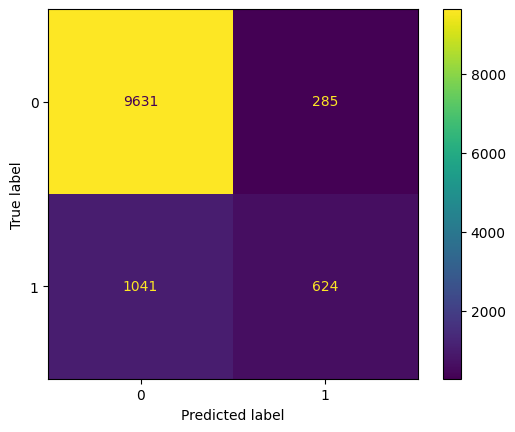

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)
displog = ConfusionMatrixDisplay(cm,display_labels=logreg.classes_)
displog.plot()


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print ('The Logistic Regression Model Accuracy:',accuracy)


The Logistic Regression Model Accuracy: 0.8855021155340644


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.97      0.94      9916
           1       0.69      0.37      0.48      1665

    accuracy                           0.89     11581
   macro avg       0.79      0.67      0.71     11581
weighted avg       0.87      0.89      0.87     11581



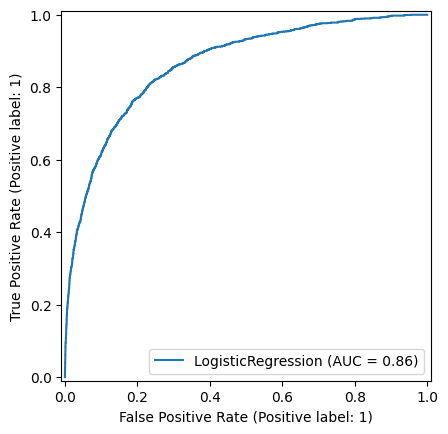

In [ ]:
from sklearn.metrics import RocCurveDisplay
Logreg_roc = RocCurveDisplay.from_estimator(logreg, X_test, y_test)


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_prednb=nb.predict(X_test)


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_prednb))


              precision    recall  f1-score   support

           0       0.93      0.89      0.91      9916
           1       0.48      0.58      0.52      1665

    accuracy                           0.85     11581
   macro avg       0.70      0.74      0.72     11581
weighted avg       0.86      0.85      0.85     11581



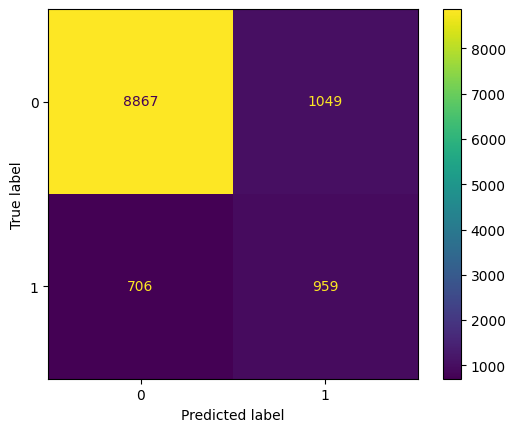

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
nb_cm = confusion_matrix(y_test, y_prednb, labels = nb.classes_)
nb_cm = ConfusionMatrixDisplay(nb_cm, display_labels = nb.classes_)
nb_cm.plot()


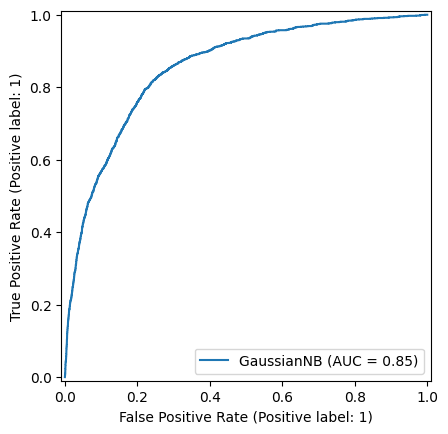

In [ ]:
from sklearn.metrics import RocCurveDisplay
nb_roc = RocCurveDisplay.from_estimator(nb, X_test, y_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)

y_pred_rf1 = rf1.predict(X_test)

from sklearn.metrics import classification_report
print("Classification report for RF")
print(classification_report(y_test,y_pred_rf1))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for RF")
rf_cm=confusion_matrix(y_test,y_pred_rf1)
disp1=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels = rf1.classes_)

Classification report for RF
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9916
           1       0.76      0.62      0.68      1665

    accuracy                           0.92     11581
   macro avg       0.85      0.79      0.82     11581
weighted avg       0.91      0.92      0.91     11581

confusion_matrix for RF


In [ ]:
RandomForestClassifier(oob_score=True)

RandomForestClassifier(oob_score=True)

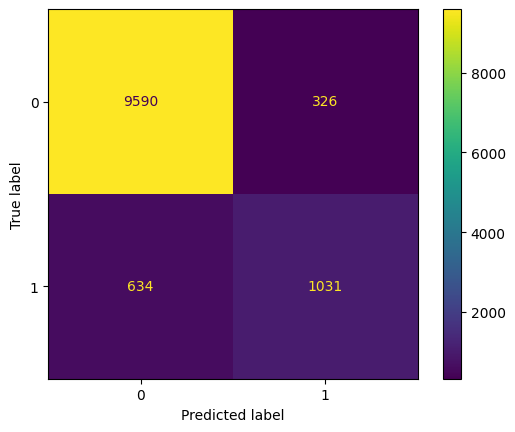

In [ ]:
disp1.plot()

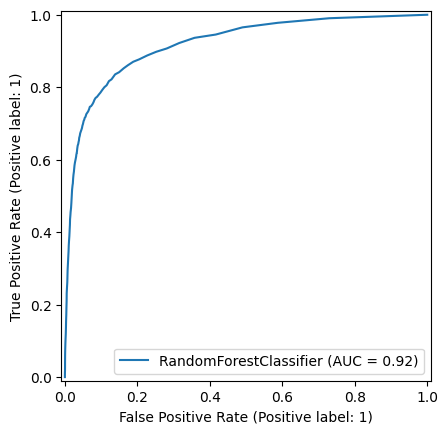

In [ ]:
rf1_roc = RocCurveDisplay.from_estimator(rf1, X_test, y_test)

In [ ]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()


params_rf = {'n_estimators': [50, 100, 200]}

rf_gs = GridSearchCV(rf, params_rf, cv=15)

rf_gs.fit(X_train, y_train)

rf_best = rf_gs.best_estimator_

print(rf_gs.best_params_)

y_pred_rf = rf_best.predict(X_test)

from sklearn.metrics import classification_report
print("Classification report for RF")
print(classification_report(y_test,y_pred_rf))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for RF")
rf_cm=confusion_matrix(y_test,y_pred_rf)
disp=ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels = rf_best.classes_)


{'n_estimators': 200}
Classification report for RF
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9916
           1       0.76      0.62      0.68      1665

    accuracy                           0.92     11581
   macro avg       0.85      0.79      0.82     11581
weighted avg       0.91      0.92      0.91     11581

confusion_matrix for RF


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf2 = RandomForestClassifier()


params_rf2 = {'n_estimators': [50, 100, 200]}


rf2_gs = GridSearchCV(rf2, params_rf2, cv=10)


rf2_gs.fit(X_train, y_train)


rf2_best = rf2_gs.best_estimator_


print(rf2_gs.best_params_)


y_pred_rf2 = rf2_best.predict(X_test)


from sklearn.metrics import classification_report
print("Classification report for RF")
print(classification_report(y_test,y_pred_rf2))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for RF")
rf2_cm=confusion_matrix(y_test,y_pred_rf2)
disp=ConfusionMatrixDisplay(confusion_matrix=rf2_cm,display_labels = rf2_best.classes_)


{'n_estimators': 200}
Classification report for RF
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9916
           1       0.76      0.63      0.69      1665

    accuracy                           0.92     11581
   macro avg       0.85      0.80      0.82     11581
weighted avg       0.91      0.92      0.91     11581

confusion_matrix for RF


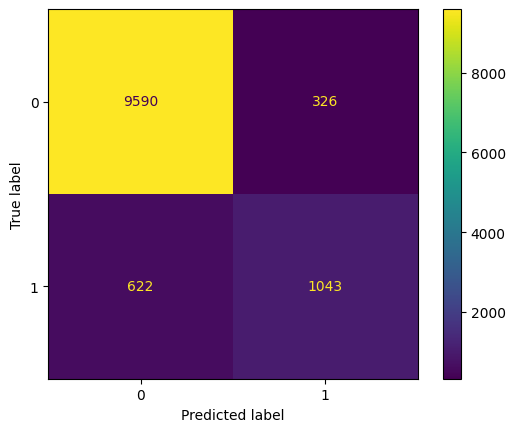

In [ ]:
disp.plot()

In [ ]:
from pandas.io.api import read_feather

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rft = RandomForestClassifier()


params_rft = {'n_estimators': [50, 100, 200, 500], 'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]}


rft_gs = GridSearchCV(rf, params_rft, cv=15)


rft_gs.fit(X_train, y_train)

rft_best = rft_gs.best_estimator_


print(rft_gs.best_params_)


y_pred_rft = rft_best.predict(X_test)

from sklearn.metrics import classification_report
print("Classification report for RF")
print(classification_report(y_test,y_pred_rft))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for RF")
rft_cm=confusion_matrix(y_test,y_pred_rft)
dispt=ConfusionMatrixDisplay(confusion_matrix=rft_cm,display_labels = rft_best.classes_)



{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Classification report for RF
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9916
           1       0.76      0.63      0.69      1665

    accuracy                           0.92     11581
   macro avg       0.85      0.80      0.82     11581
weighted avg       0.91      0.92      0.92     11581

confusion_matrix for RF


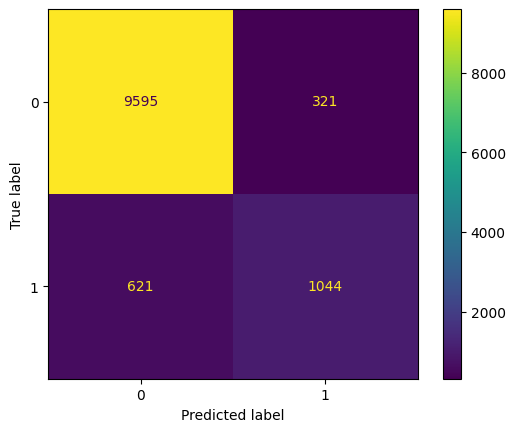

In [ ]:
dispt.plot()

In [ ]:
dispt_roc= RocCurveDisplay.from_estimator(rft, X_test, y_test)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
dt1 = pd.read_csv('/content/loan_approval_data_clean.csv')
dt1.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,90000,3,2,35000,12.42,0.39,1,14,0,35000
1,131004,9,5,30000,7.90,0.23,1,13,0,30000
2,150000,9,0,25000,11.89,0.17,1,11,0,25000
3,132000,3,2,25000,16.82,0.22,1,17,0,25000
4,80000,2,0,25000,10.25,0.31,1,11,0,25000


In [ ]:
X = dt1.drop(['max_allowed_loan','loan_approval_status','loan_intent', 'payment_default_on_file'], axis=1)
y = dt1['max_allowed_loan']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)


In [ ]:
print('Whole Data shape', dt1.shape)
print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)

Whole Data shape (57901, 10)
X_train shape (46320, 6)
X_test shape (11581, 6)


In [ ]:
X.columns

Index(['income', 'emplyment_length', 'loan_amount', 'loan_interest_rate',
       'loan_income_ratio', 'credit_history_length'],
      dtype='object')

In [ ]:
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)
print("The full Regression Decision Tree Levels: ", regressor.tree_.max_depth)

The full Regression Decision Tree Levels:  40


In [ ]:
# Limit the tree growth to 4 levels
#pruned_regressor = DecisionTreeRegressor(max_depth=6)
#pruned_regressor.fit(X_train, y_train)

# To make predictions on the test set, ues the predict method:
#y_pred_pruned = pruned_regressor.predict(X_test)




In [ ]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('R2:', metrics.r2_score(y_test, y_pred))


Mean Absolute Error: 13913.712949371098
Mean Squared Error: 888491715.6546307
R2: 0.6013596808534258


In [ ]:
#print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_pruned))
#print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_pruned))
#print('R2:', metrics.r2_score(y_test, y_pred_pruned))


In [ ]:
dt2 = pd.read_csv('/content/loan_approval_data_clean.csv')
dt2.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,90000,3,2,35000,12.42,0.39,1,14,0,35000
1,131004,9,5,30000,7.90,0.23,1,13,0,30000
2,150000,9,0,25000,11.89,0.17,1,11,0,25000
3,132000,3,2,25000,16.82,0.22,1,17,0,25000
4,80000,2,0,25000,10.25,0.31,1,11,0,25000


In [ ]:
X2 = dt2.drop(['max_allowed_loan'], axis=1)
y2 = dt2['max_allowed_loan']

from sklearn.model_selection import train_test_split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=5)

In [ ]:
print('Whole Data shape', dt2.shape)
print('X_train shape', X2_train.shape)
print('X_test shape', X2_test.shape)

Whole Data shape (57901, 10)
X_train shape (46320, 9)
X_test shape (11581, 9)


In [ ]:
X2.columns

Index(['income', 'emplyment_length', 'loan_intent', 'loan_amount',
       'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file',
       'credit_history_length', 'loan_approval_status'],
      dtype='object')

In [ ]:
regressor2 = DecisionTreeRegressor()
regressor.fit(X2_train, y2_train)
y2_pred = regressor.predict(X2_test)
print("The full Regression Decision Tree Levels: ", regressor.tree_.max_depth)

The full Regression Decision Tree Levels:  35


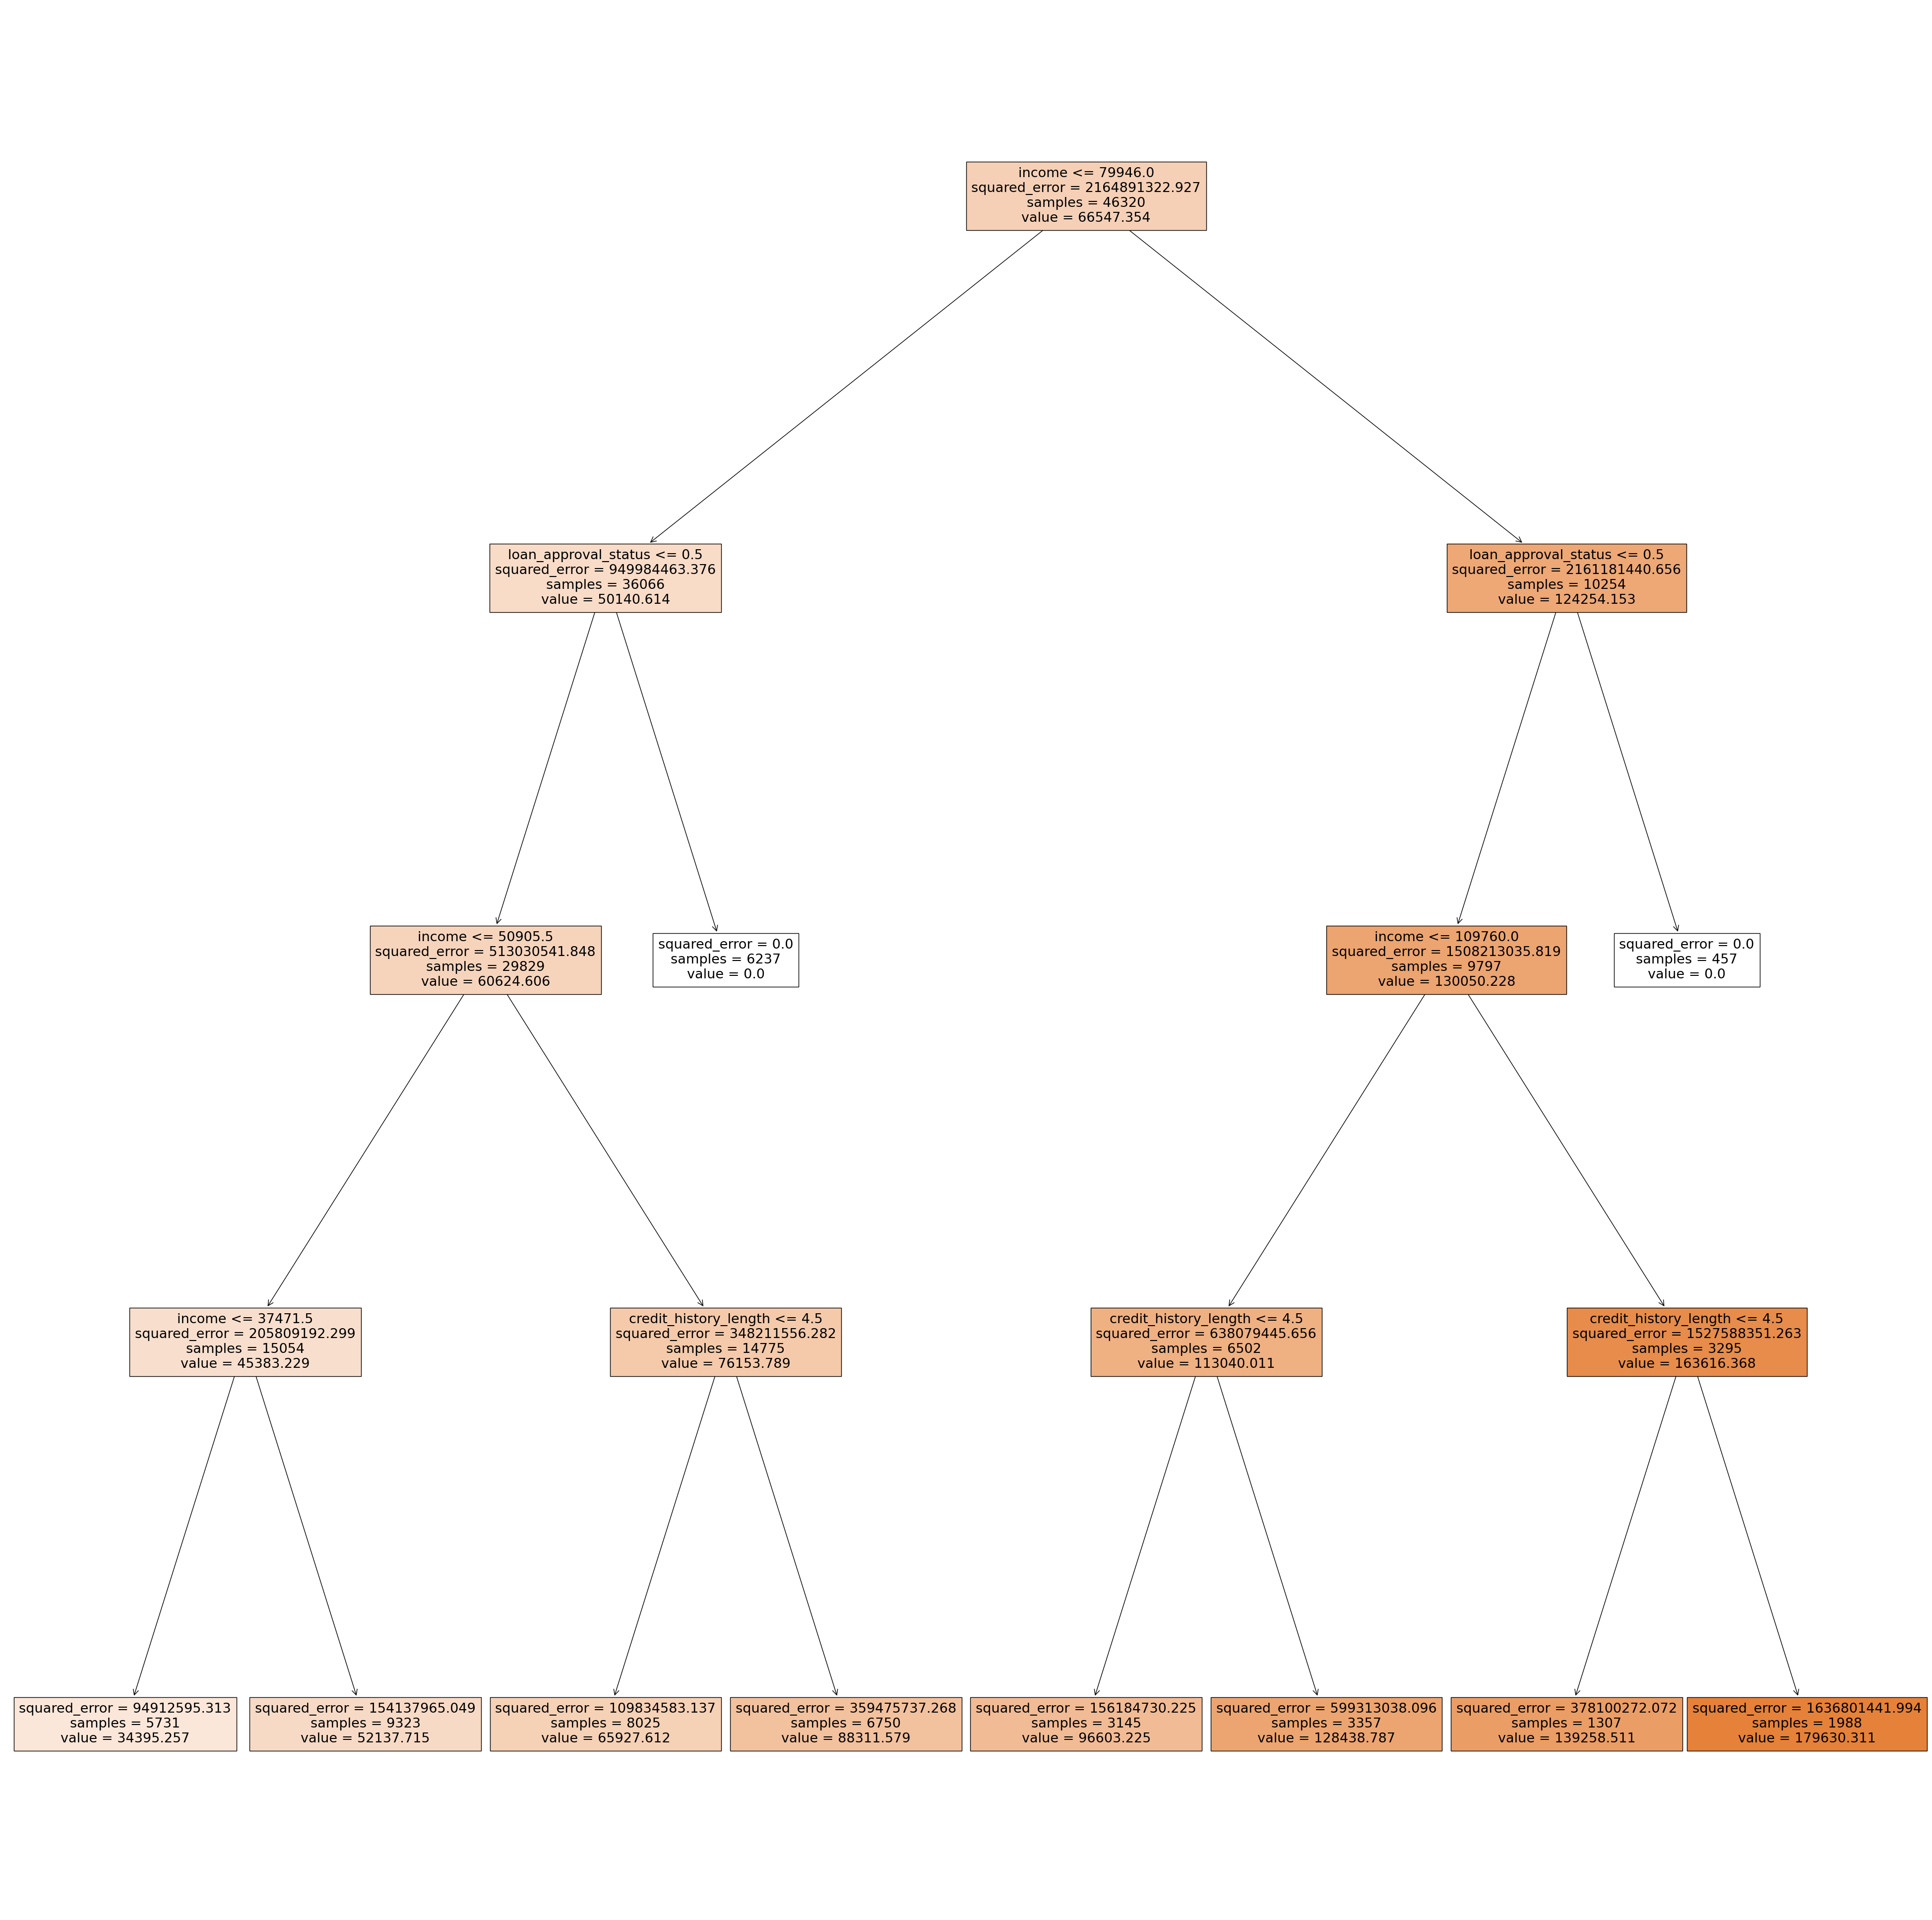

In [ ]:

pruned_regressor = DecisionTreeRegressor(max_depth=4)
pruned_regressor.fit(X2_train, y2_train)

y2_pred_pruned = pruned_regressor.predict(X2_test)

pruned_Tree_model = plt.figure(figsize=(50,50))
pruned_Tree_model_Graph = tree.plot_tree(pruned_regressor, feature_names=list(X2_train.columns), filled=True)


In [ ]:
pruned_Tree_model.savefig("pruned_reg_decision_tree.png")


In [ ]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y2_test, y2_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y2_test, y2_pred))
print('R2:', metrics.r2_score(y2_test, y2_pred))


Mean Absolute Error: 6556.843148260081
Mean Squared Error: 275622716.5174639
R2: 0.8763361258854131


In [ ]:
print('PRUNED Mean Absolute Error:', metrics.mean_absolute_error(y2_test, y2_pred_pruned))
print('PRUNED Mean Squared Error:', metrics.mean_squared_error(y2_test, y2_pred_pruned))
print('PRUNED R2:', metrics.r2_score(y2_test, y2_pred_pruned))

PRUNED Mean Absolute Error: 10200.698667963665
PRUNED Mean Squared Error: 255422602.36262694
PRUNED R2: 0.8853993279520169


In [ ]:
data = []
data.append( {"income": 57000,
              "emplyment_length":15,
              "loan_intent":3,
              "loan_amount":25700,
              "loan_interest_rate":0.23,
              "loan_income_ratio":0.10,
              "payment_default_on_file":1,
              "credit_history_length":35,
              "loan_approval_status":0} )
prediction = pd.DataFrame(data)

prediction["max_allowed_loan"] = pruned_regressor.predict(prediction)

# Add a new column to `df2` with the predicted prices:
prediction.head()

,income,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,57000,15,3,25700,0.23,0.10,1,35,0,88311.58
